# Manual Day — Mechanics and Electrostatics

Closed-agent, ~60 min. Complete every `# FILL IN` cell, then run the check.

**Five problems — work in order; as many as time permits.**

Both halves of today are differential equations. What changes is what you're given.
In mechanics you know the state right now, the equation hands you the acceleration,
and you step forward. In electrostatics nothing steps forward. You're given the
boundary and you have to find the field everywhere inside at once.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# GIVEN — astronomical units (length in AU, time in yr); Sun fixed at the origin
GM = 4 * np.pi**2                  # G*M  in AU^3 / yr^2
r0 = 1.0                           # initial orbital radius (AU)

# Initial conditions chosen for a circular orbit
x, y = 1.0, 0.0                    # start one AU out along the x-axis
vx, vy = 0.0, np.sqrt(GM / r0)     # speed sqrt(GM/r) perpendicular  ->  2*pi

dt = 1e-3                          # time step (yr)
nsteps = int(1.0 / dt)            # one full period (T = 1 yr at r0 = 1 AU)

# Storage for the trajectory and the total energy
xs = np.zeros(nsteps)
ys = np.zeros(nsteps)
E = np.zeros(nsteps)
t = np.linspace(0.0, nsteps * dt, nsteps)

## Problem 1 — circular orbit and energy conservation

A unit-mass planet moves under the central gravitational pull of a fixed Sun,
$\mathbf{a} = -GM\,\mathbf{r}/r^{3}$. With the initial conditions above the orbit
is a **circle of radius 1 AU** traced once per year, and the total energy

$$E = \tfrac{1}{2}v^{2} - \frac{GM}{r}$$

is conserved at $E_0 = \tfrac12(2\pi)^2 - 4\pi^2 = -2\pi^2 \approx -19.739$.

This is an initial value problem. You know where the planet is and how fast it's
going, so you can take a step, and then another.

Integrate with **Euler–Cromer** (semi-implicit Euler): update the velocity first, then
advance the position with that new velocity. That one reordering is what keeps the
energy bounded. Position-first Euler makes the energy climb and the orbit spiral out,
which is Problem 5, so don't code it here.

In [10]:
# FILL IN: Euler–Cromer integration loop — velocity first, then position
for i in range(nsteps):
    r = np.hypot(x, y) 
    print(r)                    # distance to the Sun
    ax = -GM*x/(r**3)                              # central-force acceleration, x  (-GM*x/r**3)
    ay = -GM*y/(r**3)                               # central-force acceleration, y
    vx += dt*ax                              # Euler–Cromer: VELOCITY first
    vy += dt*ay
    x += dt*vx                               # then advance POSITION with new v
    y += dt*vy
    xs[i], ys[i] = x, y                    # record the trajectory
    E[i] = 0.5*(vx**2+vy**2)-GM/r                             # total specific energy  0.5*v^2 - GM/r

1.0
0.999980261375664
0.9999605239203139
0.9999407884133301
0.9999210556341086
0.9999013263620296
0.9998816013764269
0.9998618814565577
0.999842167381571
0.9998224599304769
0.999802759882116
0.9997830680151284
0.9997633851079227
0.9997437119386454
0.9997240492851498
0.9997043979249651
0.9996847586352656
0.9996651321928398
0.9996455193740595
0.999625920954849
0.9996063377106541
0.9995867704164111
0.9995672198465161
0.9995476867747943
0.999528171974469
0.9995086762181304
0.9994892002777055
0.9994697449244265
0.9994503109288007
0.9994308990605788
0.9994115100887253
0.9993921447813868
0.9993728039058615
0.9993534882285686
0.9993341985150177
0.9993149355297779
0.999295700036447
0.9992764927976213
0.9992573145748648
0.9992381661286781
0.9992190482184691
0.9991999616025211
0.9991809070379633
0.9991618852807397
0.9991428970855791
0.9991239432059648
0.9991050243941035
0.9990861414008959
0.999067294975906
0.9990484858673305
0.9990297148219697
0.9990109825851959
0.9989922899009248
0.9989736375115

initial energy E[0]  = -19.7384   (expected -19.7392)
final   energy E[-1] = -19.7384
PASSED: bounded energy and near-circular orbit


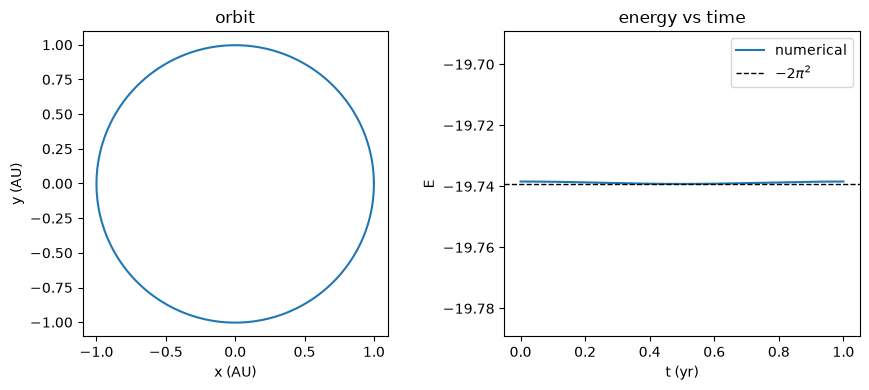

In [11]:
# CHECK — energy conservation and constant radius (given; just run it)
E0 = 0.5 * (2 * np.pi) ** 2 - GM / r0        # = -2*pi**2 ~ -19.739
print(f"initial energy E[0]  = {E[0]:.4f}   (expected {E0:.4f})")
print(f"final   energy E[-1] = {E[-1]:.4f}")

radius = np.hypot(xs, ys)
assert np.allclose(radius, 1.0, atol=1e-2), "radius drifted away from 1 AU"
assert np.max(np.abs(E - E0)) < 1e-1, "energy drifted too far"
print("PASSED: bounded energy and near-circular orbit")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
a1.plot(xs, ys); a1.set_aspect("equal"); a1.set_title("orbit")
a1.set_xlabel("x (AU)"); a1.set_ylabel("y (AU)")
a2.plot(t, E, label="numerical")
a2.axhline(E0, ls="--", c="k", lw=1, label=r"$-2\pi^2$")
a2.ticklabel_format(axis="y", useOffset=False)   # show real values, not an offset
a2.set_ylim(E0 - 0.05, E0 + 0.05)                # a band you can judge "flat" against
a2.set_title("energy vs time"); a2.legend()
a2.set_xlabel("t (yr)"); a2.set_ylabel("E")
plt.tight_layout(); plt.show()

## Problem 2 — Laplace's equation on a square

There's no time in this problem. Laplace's equation $\nabla^2 V = 0$ says every point
sits at the average of its surroundings, and the boundary fixes the rest. That's a
boundary value problem, and you solve it by relaxation: guess, sweep, repeat until the
guess stops moving.

For the discrete version, take the central second difference in each direction, which
is just the central difference applied twice:

$$\frac{\partial^2 V}{\partial x^2} \approx \frac{V_{i+1,j} - 2V_{i,j} + V_{i-1,j}}{h^2},
\qquad
\frac{\partial^2 V}{\partial y^2} \approx \frac{V_{i,j+1} - 2V_{i,j} + V_{i,j-1}}{h^2}.$$

Add them, set $\nabla^2 V = 0$, and $h^2$ divides out, leaving the five-point stencil

$$V_{i,j} \leftarrow \tfrac14\big(V_{i+1,j}+V_{i-1,j}+V_{i,j+1}+V_{i,j-1}\big),$$

swept over the interior with the boundary held fixed. The grid spacing dropping out is
particular to Laplace: put a charge on the right-hand side and $h^2$ comes back.

Write each sweep into a fresh copy of the array. If you write in place you're running
Gauss-Seidel instead, which converges faster and isn't what we're doing here.

You'll run the same solver twice and change nothing but the boundary values. Those are
the only physical input. The box size doesn't matter, since Laplace's equation has no
scale in it, and neither does your starting guess, since the solution is unique.

**Boundary A, a ramp.** Every edge set to $V = x$. A linear function already satisfies
the stencil exactly, so relaxation should hand back $V = x$ across the interior, and
the only error left is wherever you stopped.

**Boundary B, one hot edge.** Left edge at 5 V, the other three at $V = 0$. Nobody
gives you the answer here, but you can still get one number exactly. Superpose four
rotated copies and every edge is at 5 V, so the potential is 5 everywhere, and by
symmetry each copy contributes a quarter of that at the center. So $V$ at the center
is exactly $5/4$, and I want to see you check it.

In [28]:
# GIVEN — one grid, two sets of boundary conditions.
N = 41
xs = np.linspace(0.0, 1.0, N)
X, Y = np.meshgrid(xs, xs, indexing="xy")
tol, max_iter = 1e-6, 50000

def ramp_bc():
    """Boundary A: every edge set to V = x."""
    V = np.zeros((N, N))
    V[0, :], V[-1, :] = X[0, :], X[-1, :]
    V[:, 0], V[:, -1] = X[:, 0], X[:, -1]
    return V

def hot_edge_bc(V0=5.0):
    """Boundary B: left edge at V0, the other three at V = 0."""
    V = np.zeros((N, N))
    V[:, 0] = V0
    return V

In [31]:
# FILL IN: one Jacobi sweep repeated until the largest change drops below tol.
#          Only write to the interior, so the boundary stays where it was put.
def relax(V, tol=tol, max_iter=max_iter):
    for it in range(max_iter):
        Vnew = V.copy()
        for i in range(1, len(V)-1):
            for j in range(1, len(V[0])-1):
                Vnew[i, j] = 0.25*(V[i+1, j] + V[i-1,j]+V[i,j+1] + V[i,j-1])   # the four-neighbor average
        change = np.max(Vnew-V)                # largest change this sweep
        V = Vnew
        if change<=tol:
            break
    return V, it + 1

A, ramp:       2536 sweeps, max|V - x| = 3.22e-04
B, hot edge:   2832 sweeps, V(center) = 1.249677   (symmetry says exactly 1.25)
              off by 3.2e-04, which is how far from converged you stopped, not a flaw
OK


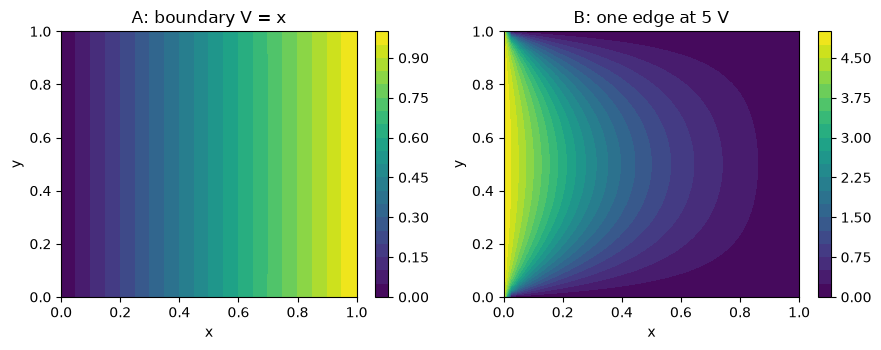

In [32]:
# CHECK — do not edit
VA, itA = relax(ramp_bc())
errA = np.max(np.abs(VA[1:-1, 1:-1] - X[1:-1, 1:-1]))
print("A, ramp:      %5d sweeps, max|V - x| = %.2e" % (itA, errA))
assert errA < 1e-2, "a ramp satisfies the stencil exactly, so this should come back clean"

VB, itB = relax(hot_edge_bc())
center = VB[N//2, N//2]
print("B, hot edge:  %5d sweeps, V(center) = %.6f   (symmetry says exactly 1.25)" % (itB, center))
print("              off by %.1e, which is how far from converged you stopped, not a flaw" % abs(center - 1.25))
assert abs(center - 1.25) < 5e-3, "the center has to be V0/4"
print("OK")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, V, t in [(a1, VA, "A: boundary V = x"), (a2, VB, "B: one edge at 5 V")]:
    c = ax.contourf(X, Y, V, 20, cmap="viridis"); fig.colorbar(c, ax=ax)
    ax.set_title(t); ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout();

## Problem 3 — Quadratic drag: terminal velocity and the drag-free limit

An object of mass $m = 1\,\mathrm{kg}$ falls from rest under gravity plus a
**quadratic drag** force. Taking *down as negative*, the net force is

$$F = -m g - k_2\, v\,|v|, \qquad k_2 = \frac{m g}{v_t^{2}},$$

so the drag exactly cancels gravity once the object reaches the **terminal
speed** $v_t$. Integrate the 1D fall from rest with plain **Euler** (velocity
first, then position: `v += a*dt`, then `y += v*dt`).

Run it twice:

* **With drag** ($v_t = 30\ \mathrm{m/s}$): the speed climbs and **asymptotes
  to $v_t = 30\ \mathrm{m/s}$** as the net force $\to 0$.
* **Drag effectively off** ($v_t = 10^{10}$, so $k_2 \approx 0$): the motion
  reduces to free fall, matching the analytic result $v(t) = -g\,t$ to high
  accuracy.

In [38]:
# FILL IN: Euler update for a 1D fall with quadratic drag (down is negative)
g    = 9.8      # gravitational acceleration (m/s^2)
mass = 1.0      # mass (kg)
dt   = 1e-3     # time step (s)
nsteps = 20000  # number of steps (20 s of motion)

def fall(vt):
    """Integrate a fall from rest for terminal speed vt; return (t, v) arrays."""
    k2 = g * mass / vt**2          # quadratic-drag coefficient
    v, y = 0.0, 0.0
    ts = np.zeros(nsteps)
    vs = np.zeros(nsteps)
    for i in range(nsteps):
        F = -mass*g-k2*v*np.abs(v)
        print(F)                   # net force: gravity (down, negative) + quadratic drag
        a = F/mass                    # acceleration, F/mass
        v += a*dt                   # Euler: velocity update
        y += v*dt                   # Euler: position update with new v
        ts[i], vs[i] = (i + 1) * dt, v
    return ts, vs


-9.8
-9.799998954231112
-9.799995816924891
-9.799990588083348
-9.799983267710276
-9.799973855811256
-9.799962352393653
-9.799948757466618
-9.799933071041083
-9.799915293129777
-9.799895423747202
-9.79987346290965
-9.799849410635202
-9.79982326694372
-9.799795031856853
-9.799764705398035
-9.799732287592484
-9.799697778467204
-9.799661178050984
-9.799622486374401
-9.799581703469812
-9.799538829371365
-9.799493864114984
-9.799446807738388
-9.799397660281073
-9.799346421784326
-9.799293092291213
-9.799237671846587
-9.799180160497087
-9.799120558291133
-9.799058865278932
-9.798995081512475
-9.798929207045534
-9.798861241933672
-9.798791186234228
-9.798719040006329
-9.798644803310886
-9.79856847621059
-9.798490058769922
-9.79840955105514
-9.798326953134287
-9.798242265077194
-9.798155486955467
-9.798066618842501
-9.797975660813469
-9.797882612945333
-9.79778747531683
-9.797690248008486
-9.797590931102604
-9.797489524683273
-9.797386028836362
-9.79728044364952
-9.797172769212182
-9.7970630056

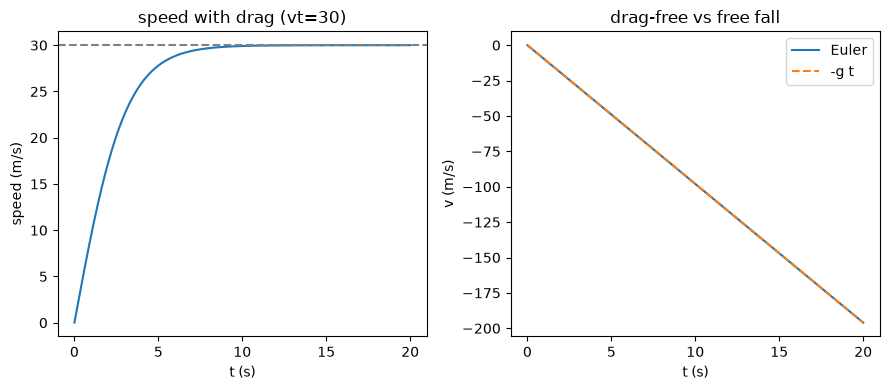

In [39]:
# CHECK — terminal velocity and the drag-free limit (given; just run it)
t1, v1 = fall(30.0)          # with drag: speed should asymptote to vt = 30 m/s
t2, v2 = fall(1e10)          # drag effectively off: pure free fall

speed_final = abs(v1[-1])
print(f"final speed with drag      = {speed_final:.4f} m/s   (expected ~30)")
assert abs(speed_final - 30.0) < 0.1, "did not reach terminal speed"

v_free = -g * t2             # analytic free fall, down is negative
err = np.max(np.abs(v2 - v_free))
print(f"max |v - (-g t)| drag-free = {err:.2e} m/s")
assert err < 1e-4, "drag-free run does not match analytic free fall"
print("PASSED: terminal velocity reached and drag-free limit matches -g t")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
a1.plot(t1, -v1); a1.axhline(30.0, ls="--", color="gray")
a1.set_title("speed with drag (vt=30)")
a1.set_xlabel("t (s)"); a1.set_ylabel("speed (m/s)")
a2.plot(t2, v2, label="Euler"); a2.plot(t2, v_free, "--", label="-g t")
a2.set_title("drag-free vs free fall"); a2.legend()
a2.set_xlabel("t (s)"); a2.set_ylabel("v (m/s)")
plt.tight_layout(); plt.show()


## Problem 4 — Challenge: Kepler's third law

Run circular orbits at several radii and measure the period of each. Kepler says
$T^2 \propto a^3$, so a log-log fit should come out with slope $3/2$.

To get the period, start at $(a, 0)$ moving in $+y$ and wait for $y$ to come back up
through zero, then interpolate between the two steps on either side of it.

**Known answers.** Slope $3/2$, and with $GM = 4\pi^2$ the period at $a = 1$ is
exactly one time unit.

In [40]:
# GIVEN — radii to try, and a timestep small enough to resolve the crossing.
radii = np.array([0.4, 0.7, 1.0, 1.5, 2.0])
dt_k = 1e-4

In [46]:
# FILL IN: integrate a circular orbit of radius a and return its period.
def period(a, dt=dt_k):

    x, y = a, 0.0
    vx, vy = 0.0, np.sqrt(GM/a)
    t, prev = 0.0, 0.0

    for _ in range(int(20/dt)):
        r = np.hypot(x, y) 
        ax = -GM*x/(r**3)                              # central-force acceleration, x  (-GM*x/r**3)
        ay = -GM*y/(r**3)                               # central-force acceleration, y
        vx += dt*ax                              
        vy += dt*ay            
        x += dt*vx                               # then advance POSITION with new v
        y += dt*vy                                        # one Euler-Cromer step, as in Problem 1
        t += dt
        if (y>0 and prev < 0):                                 # y coming back up through zero
            return t                          # interpolate onto the crossing
        prev = y
    raise RuntimeError("no complete orbit within 20 years at a = %g" % a)

a = 0.40   T =  0.2530   a^(3/2) =  0.2530
a = 0.70   T =  0.5857   a^(3/2) =  0.5857
a = 1.00   T =  1.0001   a^(3/2) =  1.0000
a = 1.50   T =  1.8372   a^(3/2) =  1.8371
a = 2.00   T =  2.8285   a^(3/2) =  2.8284

fitted exponent 1.5000   (Kepler says 1.5)
OK


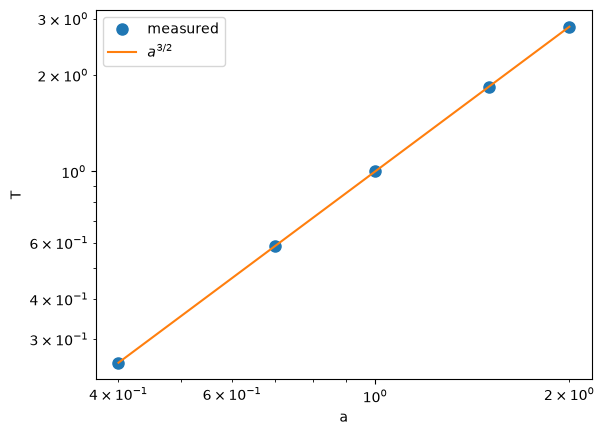

In [47]:
# CHECK — do not edit
T = np.array([period(a) for a in radii])
for a, t in zip(radii, T):
    print("a = %4.2f   T = %7.4f   a^(3/2) = %7.4f" % (a, t, a**1.5))

slope = np.polyfit(np.log(radii), np.log(T), 1)[0]
print("\nfitted exponent %.4f   (Kepler says 1.5)" % slope)
assert abs(slope - 1.5) < 0.01, "that is not Kepler's third law"
assert abs(T[2] - 1.0) < 1e-3, "a = 1 should take one time unit when GM = 4*pi^2"
print("OK")

plt.loglog(radii, T, "o", ms=8, label="measured")
plt.loglog(radii, radii**1.5, "-", label=r"$a^{3/2}$")
plt.xlabel("a"); plt.ylabel("T"); plt.legend();

## Problem 5 — Challenge: the other order

Swap the two lines from Problem 1 so the position steps with the old velocity rather than the new one. That's
plain Euler. Same force, same step size, same starting conditions.

Integrate both for a hundred orbits and plot the energy against time.

**Known answer.** Both are first order and cost the same per step, and only one of them
keeps the energy near $-2\pi^2$. Measure the drift for each, and plot the orbits.

In [48]:
# GIVEN — a long run, and the energy the orbit started with.
norbits, dt_o = 100, 1e-3
E_start = 0.5*(2*np.pi)**2 - GM

In [49]:
# FILL IN: the two update orders. One line each, and mind which velocity you use.
def orbit(velocity_first, norbits=norbits, dt=dt_o):
    x, y, vx, vy = 1.0, 0.0, 0.0, np.sqrt(GM)
    E = np.zeros(int(norbits/dt))
    for i in range(E.size):
        r = np.hypot(x, y)
        ax, ay = -GM*x/r**3, -GM*y/r**3
        if velocity_first:
            vx += dt*ax                              # Euler–Cromer: VELOCITY first
            vy += dt*ay
            x += dt*vx                               # then advance POSITION with new v
            y += dt*vy                               # velocity, then position with the new one
        else:
            x += dt*vx
            y += dt*vy
            vx += dt*ax
            vy += dt*ay                               # position with the old velocity, then velocity
        E[i] = 0.5*(vx**2 + vy**2) - GM/np.hypot(x, y)
    return E

velocity first  final E =  -19.7392   max|E - E0| = 7.79e-04
position first  final E =   -6.7755   max|E - E0| = 1.30e+01
ratio of the two drifts: 16636x
OK


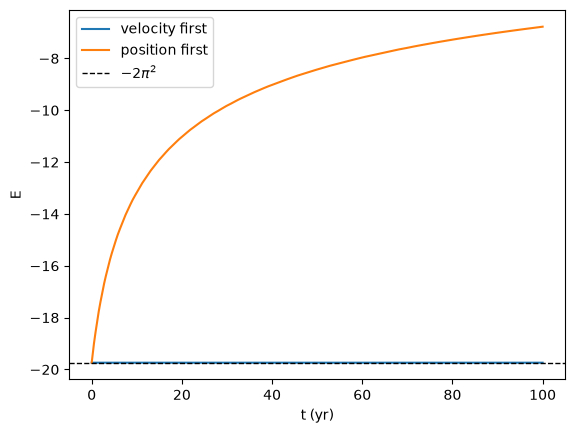

In [50]:
# CHECK — do not edit
Ec, Ee = orbit(True), orbit(False)
t = np.arange(Ec.size)*dt_o
for name, E in [("velocity first", Ec), ("position first", Ee)]:
    print("%-15s final E = %+9.4f   max|E - E0| = %.2e"
          % (name, E[-1], np.max(np.abs(E - E_start))))

assert np.max(np.abs(Ec - E_start)) < 1e-2, "velocity-first should stay near E0"
assert Ee[-1] - E_start > 1.0, "position-first should gain energy and drift off"
print("ratio of the two drifts: %.0fx" % (np.max(np.abs(Ee - E_start))
                                          / np.max(np.abs(Ec - E_start))))
print("OK")

plt.plot(t, Ec, label="velocity first")
plt.plot(t, Ee, label="position first")
plt.axhline(E_start, ls="--", c="k", lw=1, label=r"$-2\pi^2$")
plt.xlabel("t (yr)"); plt.ylabel("E"); plt.legend();